In [5]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv, norm, slogdet
from tqdm import tqdm
import os

### Exercise 5 ###

Implement function tha takes S and $\gamma$ and solve the graphical LASSO

In [46]:
def solver(S, gamma, solver_name='default'):
    if not np.allclose(S, S.T):
        raise ValueError("Matrix S must be symmetric.")
    if gamma < 0:
        raise ValueError("Gamma must be non-negative.")

    n = S.shape[0]
    X = cp.Variable((n, n), symmetric=True)

    trace_term = cp.trace(S @ X)
    logdet_term = -cp.log_det(X)

    # Efficient off-diagonal L1 penalty using masking
    mask = np.ones((n, n)) - np.eye(n)
    off_diag_l1 = cp.norm1(cp.multiply(mask, X))

    # Full objective
    objective = cp.Minimize(trace_term + logdet_term + gamma * off_diag_l1)
    constraints = [X >> 0]

    # Solve with a good solver
    prob = cp.Problem(objective, constraints)
    if solver_name == 'scs':
        prob.solve(solver=cp.SCS, eps=1e-4, max_iters=5000, warm_start=True)
    # elif solver_name == 'mosek':
    #     prob.solve(solver=cp.MOSEK)
    elif solver_name == 'default':
        prob.solve()
    else:
        raise ValueError("Unsupported solver. Use 'scs' or 'mosek'.")

    print(f"Optimal X for gamma = {gamma:.5f}:")
    print(X.value)
    print("\n#########################################\n")
    return X.value

### Exercise 6 ###
Given the S matrix compute th epoints on thr trade - off curve

In [47]:
S = np.array([
    [1.00, -0.50,  0.10, -0.90],
    [-0.50, 1.25, -0.05,  1.05],
    [0.10, -0.05,  0.26, -0.09],
    [-0.90, 1.05, -0.09,  5.17]
])

In [48]:
def trade_off(S, gammas, method, epsilon=1e-5):

    x_points = []
    y_points = []
    n_no_zeros = []

    interval_zero = [-epsilon, epsilon]
    for gamma in gammas:

        X = method(S, gamma)

        x_points.append(np.trace(S @ X) - np.log(np.linalg.det(X)))

        off_diag_mask = ~np.eye(X.shape[0], dtype=bool)
        off_diag_l1 = np.sum(np.abs(X[off_diag_mask]))
        
        y_points.append(off_diag_l1)

        n_no_zeros.append(np.sum((X[off_diag_mask] < interval_zero[0]) | (X[off_diag_mask] > interval_zero[1])))

    plt.figure(figsize=(8, 6))
    plt.plot(x_points, y_points, marker='o', label='Trade-off Curve')
    plt.xlabel('Trace - LogDet')
    plt.ylabel('L1 Norm of Off-Diagonal Elements')
    plt.title('Trade-off Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.plot(gammas, n_no_zeros, marker='o', label='Number of Non Zeros')
    plt.xlabel('Gamma')
    plt.ylabel('Number of Non Zeros in X')
    plt.title('Number of Non Zeros vs Gamma')
    plt.legend()
    plt.grid(True)
    plt.show()

Optimal X for gamma = 0.01000:
[[ 1.35862159e+00  3.96322326e-01 -3.57232862e-01  1.48617820e-01]
 [ 3.96322326e-01  1.07921879e+00  1.08920936e-06 -1.48871200e-01]
 [-3.57232862e-01  1.08920936e-06  3.96980828e+00  7.25147252e-05]
 [ 1.48617820e-01 -1.48871200e-01  7.25147252e-05  2.48947588e-01]]

#########################################

Optimal X for gamma = 0.01668:
[[ 1.34514640e+00  3.87395152e-01 -3.29251789e-01  1.47706247e-01]
 [ 3.87395152e-01  1.07222753e+00  5.52289025e-07 -1.48116608e-01]
 [-3.29251789e-01  5.52289025e-07  3.95159245e+00  3.67248311e-05]
 [ 1.47706247e-01 -1.48116608e-01  3.67248311e-05  2.48257934e-01]]

#########################################

Optimal X for gamma = 0.02783:
[[ 1.32400286e+00  3.72860246e-01 -2.83260571e-01  1.46189830e-01]
 [ 3.72860246e-01  1.06093694e+00  3.13990933e-07 -1.46860100e-01]
 [-2.83260571e-01  3.13990933e-07  3.92478006e+00  1.16759840e-05]
 [ 1.46189830e-01 -1.46860100e-01  1.16759840e-05  2.47116621e-01]]

###########

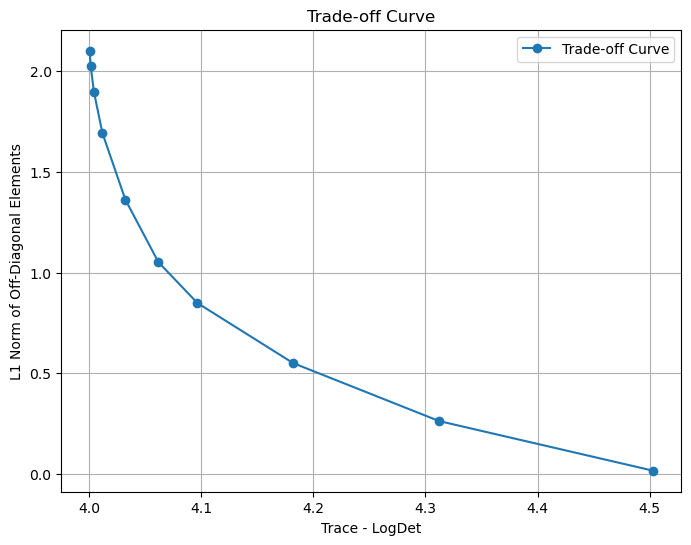

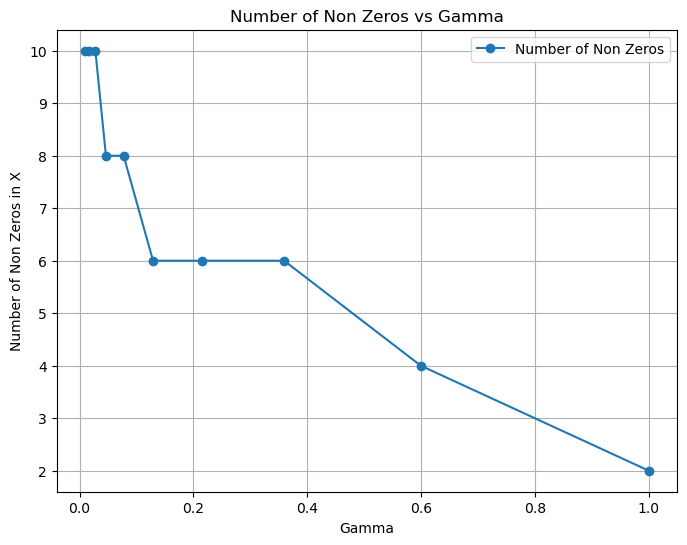

In [49]:
gammas = np.logspace(-2, 0, 10)

trade_off(S, gammas, solver)

### Exercise 7 ###

Implement proximal gradient method for solving graphical LASSO problem

In [28]:
# def proximal_h(X_minus_S, gamma):
#     """Proximal operator for h(X) with respect to U"""
#     U = np.zeros_like(X_minus_S)
#     n = X_minus_S.shape[0]
    
#     for i in range(n):
#         for j in range(n):
#             if i != j:
#                 U[i,j] = max(-gamma, min(gamma, X_minus_S[i,j]))
    
#     return U

def proximal_h(X_minus_S, gamma):
    """Proximal operator for h(X) with respect to U"""
    U = np.zeros_like(X_minus_S)
    
    # Create a mask for off-diagonal elements
    mask = ~np.eye(X_minus_S.shape[0], dtype=bool)
    X_off_diag = X_minus_S[mask]
    
    # Clip off-diagonal elements between -gamma and gamma
    U[mask] = np.clip(X_off_diag, -gamma, gamma)
    
    return U

def is_pos_def(X):
    """Check if matrix is positive definite"""
    try:
        np.linalg.cholesky(X)
        return True
    except np.linalg.LinAlgError:
        return False

# def proximal_operator_h(Z, gamma):
#     """Proximal operator for h(X) = γ∑|X_ij| for i≠j"""
#     X_new = Z.copy()
#     n = Z.shape[0]
    
#     for i in range(n):
#         for j in range(n):
#             if i != j:
#                 if Z[i,j] > gamma:
#                     X_new[i,j] -= gamma
#                 elif Z[i,j] < -gamma:
#                     X_new[i,j] += gamma
#                 else:
#                     X_new[i,j] = 0
    
#     return X_new

def proximal_operator_h(Z, gamma):
    """Proximal operator for h(X) = γ∑|X_ij| for i≠j"""
    X_new = Z.copy()
    np.fill_diagonal(X_new, np.diag(Z))  # keep the diagonal unchanged

    # Apply soft-thresholding only on the off-diagonal elements
    mask = ~np.eye(Z.shape[0], dtype=bool)
    Z_off_diag = Z[mask]
    
    X_new[mask] = np.sign(Z_off_diag) * np.maximum(np.abs(Z_off_diag) - gamma, 0)
    
    return X_new

def compute_g(X, S):
    """Compute g(X) = tr(SX) - ln(det(X))"""
    return np.trace(S @ X) - slogdet(X)[1]

def compute_h(X, gamma):
    """Compute h(X) = γ∑|X_ij| for i≠j"""
    n = X.shape[0]
    h_sum = 0
    for i in range(n):
        for j in range(n):
            if i != j:
                h_sum += abs(X[i,j])
    return gamma * h_sum

def compute_gradient_g(X, S):
    """Compute gradient of g(X) = tr(SX) - ln(det(X))"""
    return S - inv(X)

def proximal_gradient_glasso(S, gamma, tol=1e-2, max_iter=1000, X_init=None, verbose=False, beta=0.5, t=1.0):
    """
    Solve the graphical LASSO problem using proximal gradient method
    
    Parameters:
    -----------
    S : array-like
        Empirical covariance matrix
    gamma : float
        Regularization parameter
    tol : float
        Tolerance for stopping criterion (duality gap)
    max_iter : int
        Maximum number of iterations
    X_init : array-like or None
        Initial guess for precision matrix. If None, identity matrix is used
    verbose : bool
        Whether to print progress information
        
    Returns:
    --------
    X : array-like
        Estimated precision matrix
    duality_gaps : list
        History of duality gaps during optimization
    """
    n = S.shape[0]
    X = np.eye(n) if X_init is None else X_init.copy()  # Initialization
    # t = 1.0        # Initial step size
    # beta = 0.3     # Backtracking line search parameter
    
    # For tracking convergence
    duality_gaps = []
    
    for k in tqdm(range(max_iter), disable=not verbose):
        grad_g_X = compute_gradient_g(X, S)
        
        # Backtracking line search
        while True:
            # Compute Z_k = X_k - t_k ∇g(X_k)
            Z = X - t * grad_g_X
            
            # Apply proximal operator to get X_{k+1}
            X_next = proximal_operator_h(Z, t * gamma)
            
            # Check if X_next is positive definite
            if not is_pos_def(X_next):
                t *= beta
                continue
            
            # Check the sufficient decrease condition
            g_X_next = compute_g(X_next, S)
            g_X = compute_g(X, S)
            diff = X_next - X
            rhs = g_X + np.sum(grad_g_X * diff) + (1/(2*t)) * np.square(norm(diff, 'fro'))
            
            if g_X_next <= rhs:
                break
            
            t *= beta
        
        # Compute the dual variable U based on optimality condition
        X_inv = inv(X_next)
        U = proximal_h(X_inv - S, gamma)
        
        # Compute duality gap
        if is_pos_def(S + U):
            primal_obj = compute_g(X_next, S) + compute_h(X_next, gamma)
            dual_obj = slogdet(S + U)[1] + n
            delta = primal_obj - dual_obj
            #Print primal and dual objective values
            if verbose and k % 100 == 0:
                print(f"Iteration {k+1}: Primal Obj: {primal_obj:.4f}, Dual Obj: {dual_obj:.4f}, Duality Gap: {delta:.4f}", end='\r')
        else:
            delta = np.inf
        
        duality_gaps.append(delta)
        
        # Check stopping criterion
        if delta <= tol:
            if verbose:
                print(f"Converged after {k+1} iterations with duality gap: {delta}")
            break
        
        X = X_next
    
    return X, duality_gaps

# Ensure output directory exists
def ensure_dir(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)

### Exercise 8 ###

Find the precision matrix of given data while varying the $\gamma$

In [27]:
ensure_dir('outputs')
    
# Load S&P 500 data
try:
    S = np.loadtxt('data/sp500.txt')
    print(f"Loaded covariance matrix of shape {S.shape}")
except FileNotFoundError:
    print("Error: Could not find data/sp500.txt")
    print("Generating a synthetic dataset instead...")
    # Generate a synthetic dataset
    np.random.seed(42)
    n = 100
    X = np.random.randn(2*n, n)
    S = (X.T @ X) / (2*n)

# Ensure matrix is positive definite
if not is_pos_def(S):
    print("Making the input matrix positive definite...")
    min_eig = np.min(np.linalg.eigvalsh(S))
    if min_eig <= 0:
        S = S + (-min_eig + 1e-6) * np.eye(S.shape[0])

# Define gamma values logarithmically spaced (from large to small)
gammas = np.logspace(-2, -1, 10)[::-1]  # 10 values from 10^-1 to 10^-2, reversed

# Track metrics for plotting
g_values = []
h_values = []
nonzeros = []
epsilon = 1e-4  # Threshold for considering an element as non-zero

# Previous solution to use as initial guess
X_prev = None

# Lists to store results in reverse order (for plotting from small to large gamma)
g_values_ordered = []
h_values_ordered = []
nonzeros_ordered = []
gammas_ordered = gammas[::-1]  # Store the original order (small to large)

for gamma in gammas:
    print(f"\nSolving with gamma = {gamma:.6f}")
    
    # Solve graphical LASSO using previous solution as initial guess if available
    X_opt, duality_gaps = proximal_gradient_glasso(
        S, gamma, tol=1e-2, max_iter=3000, X_init=X_prev, verbose=True, beta=0.3, t=1.0
    )
    
    # Use current solution as initial guess for next iteration
    X_prev = X_opt.copy()
    
    # Calculate metrics
    g_value = compute_g(X_opt, S)
    h_value = compute_h(X_opt, 1.0)  # Using gamma=1 to get raw L1 norm
    
    # Count non-zero off-diagonal elements
    off_diag_mask = ~np.eye(X_opt.shape[0], dtype=bool)
    n_nonzero = np.sum(np.abs(X_opt[off_diag_mask]) > epsilon)
    
    # Store values for later reordering
    g_values.append(g_value)
    h_values.append(h_value)
    nonzeros.append(n_nonzero)
            
# Reorder the results for plotting (small to large gamma)
g_values_ordered = g_values[::-1]
h_values_ordered = h_values[::-1]
nonzeros_ordered = nonzeros[::-1]

# Plot trade-off curve with reordered data
plt.figure(figsize=(8, 6))
plt.plot(g_values_ordered, h_values_ordered, marker='o', linestyle='-')
plt.xlabel('g(X) = tr(SX) - ln(det(X))')
plt.ylabel('L1 Norm of Off-Diagonal Elements')
plt.title('Trade-off Curve for Graphical LASSO')
plt.grid(True)
plt.savefig('outputs/tradeoff_curve1.png')
plt.show()

# Plot the number of non-zeros as a function of gamma with reordered data
plt.figure(figsize=(8, 6))
plt.semilogx(gammas_ordered, nonzeros_ordered, marker='o', linestyle='-')
plt.xlabel('Regularization Parameter (gamma)')
plt.ylabel('Number of Non-Zero Off-Diagonal Elements')
plt.title('Sparsity vs Regularization')
plt.grid(True)
plt.savefig('outputs/sparsity_vs_gamma1.png')
plt.show()

Loaded covariance matrix of shape (494, 494)

Solving with gamma = 0.100000


  0%|          | 2/1000 [00:00<01:10, 14.24it/s]

 10%|█         | 102/1000 [00:07<01:05, 13.66it/s]

 20%|██        | 204/1000 [00:14<00:57, 13.95it/s]

 30%|███       | 302/1000 [00:21<00:48, 14.31it/s]

...

 70%|███████   | 702/1000 [00:49<00:20, 14.26it/s]

 80%|████████  | 802/1000 [00:57<00:14, 14.05it/s]

 90%|█████████ | 902/1000 [01:04<00:06, 14.51it/s]

 96%|█████████▋| 964/1000 [01:08<00:02, 13.98it/s]


KeyboardInterrupt: 